# Normal (Gaussian) Distribution — Theory & Real-Life Case Studies

The **Normal distribution** is the most important distribution in statistics. It is the natural shape for measurement error, biological traits, and — thanks to the Central Limit Theorem — the shape of averages and sums of almost anything.

**Contents**
1. Setup
2. The idea and the formula (PDF)
3. Why this exact formula? (Where it comes from)
4. Mean, variance, mode, median (with proofs)
5. Standardisation: Z-scores & the standard normal
6. The Empirical (68-95-99.7) Rule
7. CDF, percentiles & the quantile function
8. Skewness, kurtosis & shape
9. Linear combinations & sums of normals
10. Why the Normal shows up everywhere: the Central Limit Theorem
11. Normal approximations to Binomial & Poisson (with continuity correction)
12. Checking normality: QQ-plots & the Shapiro-Wilk test
13. Case study 1: Height & manufacturing tolerances
14. Case study 2: Exam scores, grading on a curve & percentile ranks
15. Case study 3: Financial returns, Value at Risk & the danger of "fat tails"
16. Case study 4: Quality control — process capability (Cp, Cpk) & Six Sigma
17. Case study 5: Confidence intervals — estimating a population mean
18. Estimating μ and σ from data (MLE)
19. Cheat-sheet, key insights & practice problems

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from math import pi, sqrt, exp, e

plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.grid"] = True
rng = np.random.default_rng(2025)

## 2. The Idea and the Formula

A continuous random variable X follows a **Normal distribution** with mean **μ** and standard deviation **σ** (written $X\sim N(\mu,\sigma^2)$) if its probability density function is the classic **bell curve**:

$$\boxed{f(x)=\frac{1}{\sigma\sqrt{2\pi}}\exp\!\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)},\qquad -\infty<x<\infty$$

* **μ (mean)** shifts the curve left/right — it is the centre of symmetry.
* **σ (standard deviation)** controls the width — larger σ means a flatter, wider curve.
* The curve is **symmetric**, **bell-shaped**, and never touches zero (the tails extend to ±∞, though the density becomes negligible quickly).
* Since X is continuous, $P(X=x)=0$ for any single point; only **areas** (intervals) have probability.

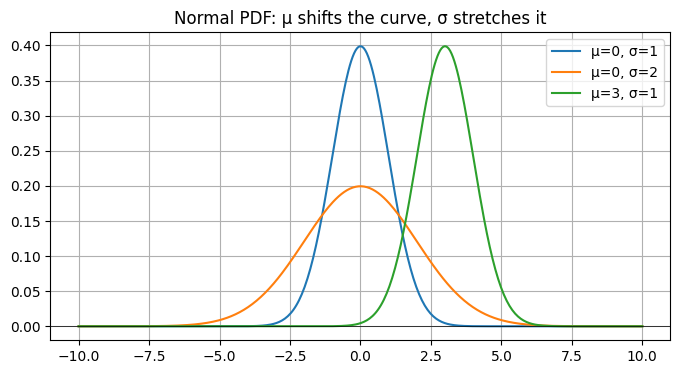

Manual formula matches scipy.stats.norm.pdf - OK


In [2]:
def normal_pdf(x, mu, sigma):
    return (1 / (sigma * sqrt(2 * pi))) * np.exp(-((x - mu) ** 2) / (2 * sigma ** 2))

x = np.linspace(-10, 10, 400)
for mu, sigma in [(0, 1), (0, 2), (3, 1)]:
    plt.plot(x, normal_pdf(x, mu, sigma), label=f"μ={mu}, σ={sigma}")
    assert np.allclose(normal_pdf(x, mu, sigma), stats.norm.pdf(x, mu, sigma))
plt.legend(); plt.title("Normal PDF: μ shifts the curve, σ stretches it"); plt.axhline(0, color="k", lw=0.5)
plt.show()
print("Manual formula matches scipy.stats.norm.pdf - OK")

## 3. Where Does This Formula Come From?

The Normal distribution isn't arbitrary — it arises as the **unique** distribution (up to shifting/scaling) satisfying very natural requirements. Two classic derivations:

**(a) Maximum entropy.** Among *all* distributions with a given mean μ and variance σ², the Normal is the one with the **least additional structure** (maximum entropy) — i.e., it encodes exactly "mean and spread" and nothing more. This is why it's the natural default when you know only the mean and variance.

**(b) Sum of many small independent effects.** If a quantity is the sum of many small, independent, roughly-equal-sized random influences (e.g., height = genes + nutrition + many small environmental factors), the sum is approximately Normal — regardless of the shape of each individual influence. This is the **Central Limit Theorem** (Section 10), and it's the real-world reason Normal curves appear so often.

**Verifying the density integrates to 1** (the famous Gaussian integral):
$$\int_{-\infty}^{\infty}e^{-x^2/2}dx=\sqrt{2\pi}\quad\Longrightarrow\quad\int_{-\infty}^{\infty}f(x)\,dx=1$$

Total area under the curve: 1.0  (should be 1)


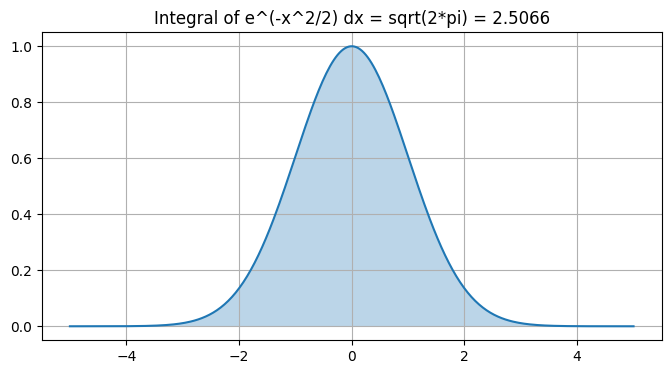

In [3]:
from scipy import integrate

mu, sigma = 5, 2
area, _ = integrate.quad(lambda x: normal_pdf(x, mu, sigma), -np.inf, np.inf)
print("Total area under the curve:", round(area, 8), " (should be 1)")

x = np.linspace(-5, 5, 300)
plt.plot(x, np.exp(-x**2 / 2))
plt.fill_between(x, np.exp(-x**2 / 2), alpha=0.3)
plt.title(f"Integral of e^(-x^2/2) dx = sqrt(2*pi) = {sqrt(2*pi):.4f}"); plt.show()

## 4. Mean, Variance, Mode & Median

For $X\sim N(\mu,\sigma^2)$:

$$E[X]=\mu\qquad\text{Var}(X)=\sigma^2\qquad\text{Mode}=\text{Median}=\text{Mean}=\mu$$

**Why mean = median = mode = μ:** the density is symmetric about x = μ (since $f(\mu+t)=f(\mu-t)$), and it's maximised at x = μ (the exponent is 0, its least negative value, there). A symmetric unimodal curve automatically has mean = median = mode at its centre.

### Proof sketch of E[X] = μ
Substitute $z=(x-\mu)/\sigma$:
$$E[X]=\int x\,f(x)\,dx=\int(\mu+\sigma z)\,\phi(z)\,dz=\mu\underbrace{\int\phi(z)dz}_{=1}+\sigma\underbrace{\int z\,\phi(z)\,dz}_{=0\text{ (odd function)}}=\mu$$
where $\phi(z)=\frac{1}{\sqrt{2\pi}}e^{-z^2/2}$ is the standard normal density (symmetric, so its mean is 0).

### Proof sketch of Var(X) = σ²
$$\text{Var}(X)=E[(X-\mu)^2]=\sigma^2\int z^2\phi(z)\,dz=\sigma^2\cdot1=\sigma^2$$
(integration by parts shows $\int z^2\phi(z)dz=1$, the variance of the standard normal).

In [4]:
mu, sigma = 20, 4
X = stats.norm(mu, sigma)

print("Mean   :", X.mean())
print("Median :", X.median())
print("Mode (analytically, at x=mu):", mu)
print("Variance:", X.var(), " Std dev:", X.std())

EX,  _ = integrate.quad(lambda x: x * normal_pdf(x, mu, sigma), -np.inf, np.inf)
EX2, _ = integrate.quad(lambda x: x**2 * normal_pdf(x, mu, sigma), -np.inf, np.inf)
print(f"\nNumeric E[X] = {EX:.5f}, Var = {EX2-EX**2:.5f}")

Mean   : 20.0
Median : 20.0
Mode (analytically, at x=mu): 20
Variance: 16.0  Std dev: 4.0

Numeric E[X] = 20.00000, Var = 16.00000


## 5. Standardisation: Z-Scores & the Standard Normal

Any Normal variable can be converted to the **standard normal** Z ~ N(0, 1):

$$Z=\frac{X-\mu}{\sigma}$$

* Z tells you **how many standard deviations** X is from the mean.
* Z > 0 means above average; Z < 0 means below average.
* This lets us use **one** table/function (`norm.cdf`) for every Normal distribution, whatever μ and σ are.

**Reverse (de-standardising):** $X=\mu+Z\sigma$.

In [5]:
mu, sigma = 68, 3          # heights in inches, say
X = stats.norm(mu, sigma)

for val in (68, 71, 62, 77):
    z = (val - mu) / sigma
    print(f"x = {val}:  z = {z:+.2f}   (i.e. {abs(z):.2f} SD {'above' if z>=0 else 'below'} the mean)")

z = 1.5
print(f"\nz = {z} corresponds to x = mu + z*sigma = {mu + z*sigma}")

print("\nP(X <= 71) directly     :", round(X.cdf(71), 4))
print("P(Z <= 1.0) standard norm:", round(stats.norm.cdf(1.0), 4), " (same, since z=(71-68)/3=1)")

x = 68:  z = +0.00   (i.e. 0.00 SD above the mean)
x = 71:  z = +1.00   (i.e. 1.00 SD above the mean)
x = 62:  z = -2.00   (i.e. 2.00 SD below the mean)
x = 77:  z = +3.00   (i.e. 3.00 SD above the mean)

z = 1.5 corresponds to x = mu + z*sigma = 72.5

P(X <= 71) directly     : 0.8413
P(Z <= 1.0) standard norm: 0.8413  (same, since z=(71-68)/3=1)


## 6. The Empirical Rule (68 – 95 – 99.7)

For any Normal distribution:

| Range | Probability |
|---|---|
| μ ± 1σ | ≈ 68.27% |
| μ ± 2σ | ≈ 95.45% |
| μ ± 3σ | ≈ 99.73% |

This is one of the most quoted facts in statistics — memorise it. Values beyond ±3σ are rare (< 0.3% combined), and this is the intuition behind flagging **outliers** and **six-sigma** quality targets (Section 16).

In [6]:
mu, sigma = 100, 15                    # e.g. IQ scores
X = stats.norm(mu, sigma)

for k in (1, 2, 3):
    p = X.cdf(mu + k*sigma) - X.cdf(mu - k*sigma)
    print(f"P(mu - {k}*sigma < X < mu + {k}*sigma) = {p:.4%}")

P(mu - 1*sigma < X < mu + 1*sigma) = 68.2689%
P(mu - 2*sigma < X < mu + 2*sigma) = 95.4500%
P(mu - 3*sigma < X < mu + 3*sigma) = 99.7300%


Simulated within +/-1 sigma: 68.1772%
Simulated within +/-2 sigma: 95.4664%
Simulated within +/-3 sigma: 99.7325%


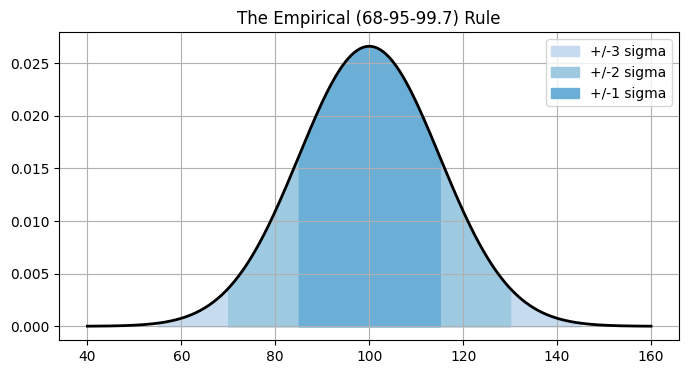

In [7]:
sim = rng.normal(mu, sigma, 1_000_000)
for k in (1, 2, 3):
    frac = np.mean((sim > mu - k*sigma) & (sim < mu + k*sigma))
    print(f"Simulated within +/-{k} sigma: {frac:.4%}")

x = np.linspace(mu - 4*sigma, mu + 4*sigma, 400)
fig, ax = plt.subplots()
ax.plot(x, X.pdf(x), "k", lw=2)
colors = ["#c6dbef", "#9ecae1", "#6baed6"]
for k, c in zip((3, 2, 1), colors):
    xs = np.linspace(mu - k*sigma, mu + k*sigma, 200)
    ax.fill_between(xs, X.pdf(xs), color=c, label=f"+/-{k} sigma")
ax.legend(); ax.set_title("The Empirical (68-95-99.7) Rule"); plt.show()

## 7. CDF, Percentiles & the Quantile Function

* **CDF** $F(x)=P(X\le x)$: area to the left of x. No closed form — computed numerically (or via the "erf" function).
* **`.ppf(q)`** (percent point function / inverse CDF / quantile function): given a probability q, returns the x-value below which that probability of the distribution lies.
* Common **critical z-values**, used constantly in confidence intervals and hypothesis tests:

In [8]:
mu, sigma = 500, 100      # e.g. SAT-style scores
X = stats.norm(mu, sigma)

print("P(X <= 650)         =", round(X.cdf(650), 4))
print("P(X > 400)          =", round(X.sf(400), 4))
print("P(450 < X < 600)    =", round(X.cdf(600) - X.cdf(450), 4))

print("\n90th percentile score =", round(X.ppf(0.90), 1))
print("Median (50th)          =", round(X.ppf(0.50), 1))
print("Bottom 10% cutoff      =", round(X.ppf(0.10), 1))

print("\nCommon two-sided critical z-values:")
for conf in (0.80, 0.90, 0.95, 0.98, 0.99):
    z = stats.norm.ppf(1 - (1 - conf) / 2)
    print(f"  {conf:.0%} confidence -> z = +/-{z:.3f}")

P(X <= 650)         = 0.9332
P(X > 400)          = 0.8413
P(450 < X < 600)    = 0.5328

90th percentile score = 628.2
Median (50th)          = 500.0
Bottom 10% cutoff      = 371.8

Common two-sided critical z-values:
  80% confidence -> z = +/-1.282
  90% confidence -> z = +/-1.645
  95% confidence -> z = +/-1.960
  98% confidence -> z = +/-2.326
  99% confidence -> z = +/-2.576


## 8. Skewness, Kurtosis & Shape

Skewness (should be 0, perfectly symmetric): 0.0
Excess kurtosis (should be 0; this DEFINES 'mesokurtic'): 0.0


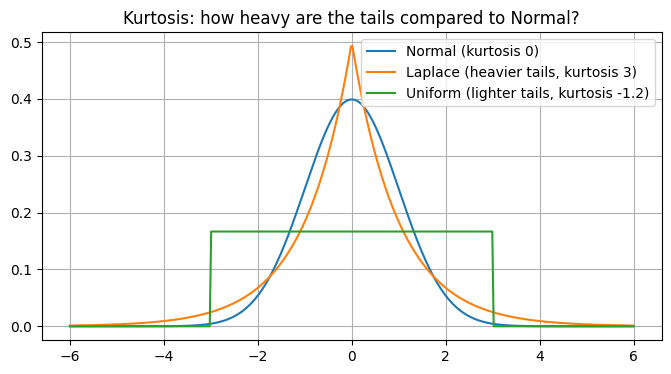

In [9]:
skew, kurt = stats.norm.stats(0, 1, moments="sk")
print("Skewness (should be 0, perfectly symmetric):", float(skew))
print("Excess kurtosis (should be 0; this DEFINES 'mesokurtic'):", float(kurt))

x = np.linspace(-6, 6, 400)
fig, ax = plt.subplots()
ax.plot(x, stats.norm.pdf(x), label="Normal (kurtosis 0)")
ax.plot(x, stats.laplace.pdf(x), label="Laplace (heavier tails, kurtosis 3)")
ax.plot(x, stats.uniform.pdf(x, -3, 6), label="Uniform (lighter tails, kurtosis -1.2)")
ax.legend(); ax.set_title("Kurtosis: how heavy are the tails compared to Normal?"); plt.show()

## 9. Linear Combinations & Sums of Normals

If $X\sim N(\mu,\sigma^2)$:
$$aX+b\sim N(a\mu+b,\ a^2\sigma^2)$$

If $X_1\sim N(\mu_1,\sigma_1^2)$ and $X_2\sim N(\mu_2,\sigma_2^2)$ are **independent**:
$$X_1+X_2\sim N(\mu_1+\mu_2,\ \sigma_1^2+\sigma_2^2)\qquad X_1-X_2\sim N(\mu_1-\mu_2,\ \sigma_1^2+\sigma_2^2)$$

**Note:** variances **always add**, even for the difference (since Var(−X₂) = Var(X₂)).

This is exactly true for Normals (not just approximately) — a special and very useful property.

In [10]:
mu1, s1 = 50, 5
mu2, s2 = 30, 4

X1 = rng.normal(mu1, s1, 500_000)
X2 = rng.normal(mu2, s2, 500_000)

print("X1+X2:  sim mean =", (X1+X2).mean().round(2), " theory =", mu1+mu2,
      "| sim var =", (X1+X2).var().round(2), " theory =", s1**2+s2**2)
print("X1-X2:  sim mean =", (X1-X2).mean().round(2), " theory =", mu1-mu2,
      "| sim var =", (X1-X2).var().round(2), " theory =", s1**2+s2**2)

bolt1 = stats.norm(30, 0.2)     # mm
bolt2 = stats.norm(45, 0.15)
total = stats.norm(30+45, sqrt(0.2**2 + 0.15**2))
print(f"\nStacked bolts: mean = {total.mean()} mm, SD = {total.std():.4f} mm")
print(f"P(total assembly > 75.5 mm) = {total.sf(75.5):.4f}")

X1+X2:  sim mean = 80.0  theory = 80 | sim var = 40.92  theory = 41
X1-X2:  sim mean = 19.98  theory = 20 | sim var = 41.07  theory = 41

Stacked bolts: mean = 75.0 mm, SD = 0.2500 mm
P(total assembly > 75.5 mm) = 0.0228


## 10. Why the Normal Shows Up Everywhere: the Central Limit Theorem (CLT)

> If $X_1,\dots,X_n$ are i.i.d. with mean μ and finite variance σ², then for large n:
> $$\bar X=\frac{X_1+\dots+X_n}{n}\approx N\!\left(\mu,\ \frac{\sigma^2}{n}\right)$$

This holds **regardless of the shape of the original distribution** (as long as variance is finite). It's why so many real-world quantities — which are often sums/averages of many small independent effects — look approximately Normal.

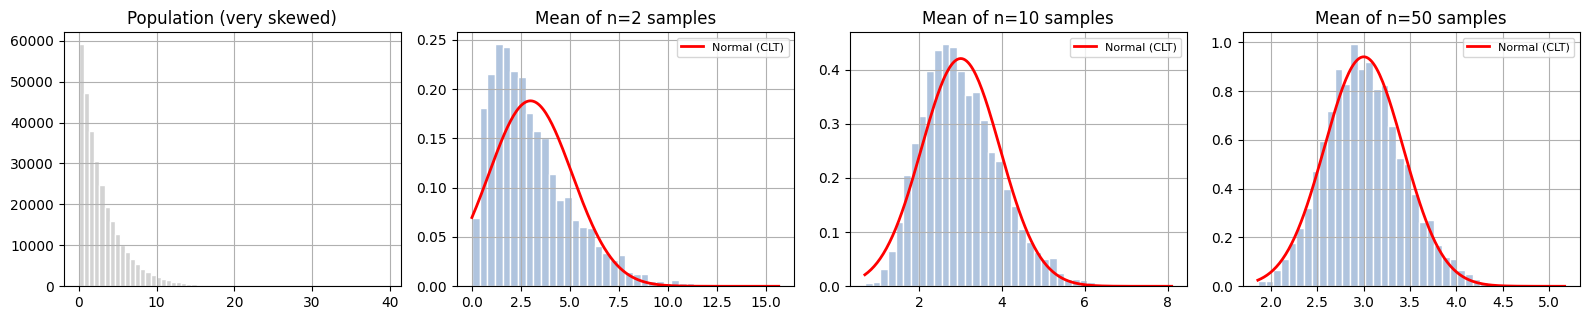

In [11]:
population = rng.exponential(scale=3, size=300_000)

fig, axes = plt.subplots(1, 4, figsize=(16, 3.3))
axes[0].hist(population, bins=60, color="lightgray", edgecolor="white"); axes[0].set_title("Population (very skewed)")

for ax, n in zip(axes[1:], [2, 10, 50]):
    means = rng.choice(population, size=(5000, n)).mean(axis=1)
    ax.hist(means, bins=40, density=True, color="lightsteelblue", edgecolor="white")
    xs = np.linspace(means.min(), means.max(), 200)
    ax.plot(xs, stats.norm.pdf(xs, 3, 3/sqrt(n)), "r-", lw=2, label="Normal (CLT)")
    ax.set_title(f"Mean of n={n} samples"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

**Consequence for measurement:** a quantity like height, blood pressure, or IQ is influenced by *many small independent factors* (genes, diet, environment...) added together — which the CLT says should look roughly Normal. That's the deep reason these traits follow bell curves.

## 11. Normal Approximation to Binomial & Poisson

* **Binomial B(n,p)** ≈ N(np, np(1−p)) when np ≥ 5 and n(1−p) ≥ 5.
* **Poisson(λ)** ≈ N(λ, λ) when λ ≳ 10–20.

Since we're approximating a **discrete** distribution with a **continuous** one, use the **continuity correction**: replace P(X ≤ k) with P(Y ≤ k + 0.5).

In [12]:
n, p = 200, 0.4
mu_b, sd_b = n*p, sqrt(n*p*(1-p))

exact = stats.binom.cdf(90, n, p)
approx_plain = stats.norm.cdf(90, mu_b, sd_b)
approx_cc    = stats.norm.cdf(90.5, mu_b, sd_b)
print(f"Binomial P(X<=90) exact              = {exact:.4f}")
print(f"Normal approx, no correction         = {approx_plain:.4f}")
print(f"Normal approx WITH continuity corr.  = {approx_cc:.4f}  <- much closer")

lam = 50
exact_p = stats.poisson.cdf(55, lam)
approx_p_cc = stats.norm.cdf(55.5, lam, sqrt(lam))
print(f"\nPoisson P(X<=55) exact = {exact_p:.4f}   Normal approx (with cc) = {approx_p_cc:.4f}")

Binomial P(X<=90) exact              = 0.9345
Normal approx, no correction         = 0.9255
Normal approx WITH continuity corr.  = 0.9352  <- much closer

Poisson P(X<=55) exact = 0.7845   Normal approx (with cc) = 0.7817


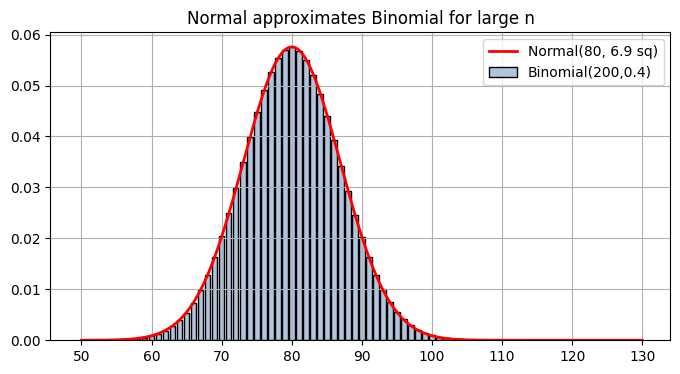

In [13]:
k = np.arange(50, 130)
xs = np.linspace(50, 130, 400)
plt.bar(k, stats.binom.pmf(k, n, p), color="lightsteelblue", edgecolor="black", label="Binomial(200,0.4)")
plt.plot(xs, stats.norm.pdf(xs, mu_b, sd_b), "r-", lw=2, label=f"Normal({mu_b:.0f}, {sd_b:.1f} sq)")
plt.legend(); plt.title("Normal approximates Binomial for large n"); plt.show()

## 12. Checking Normality: QQ-Plots & the Shapiro-Wilk Test

Before assuming data is Normal (needed for many statistical tests, control charts, etc.), **check it**.

* **QQ-plot (quantile-quantile plot):** plots the data's quantiles against theoretical Normal quantiles. If the data is Normal, points fall on a straight line.
* **Shapiro-Wilk test:** a formal hypothesis test. $H_0$: data is Normal. A small p-value (< 0.05) is evidence *against* normality.

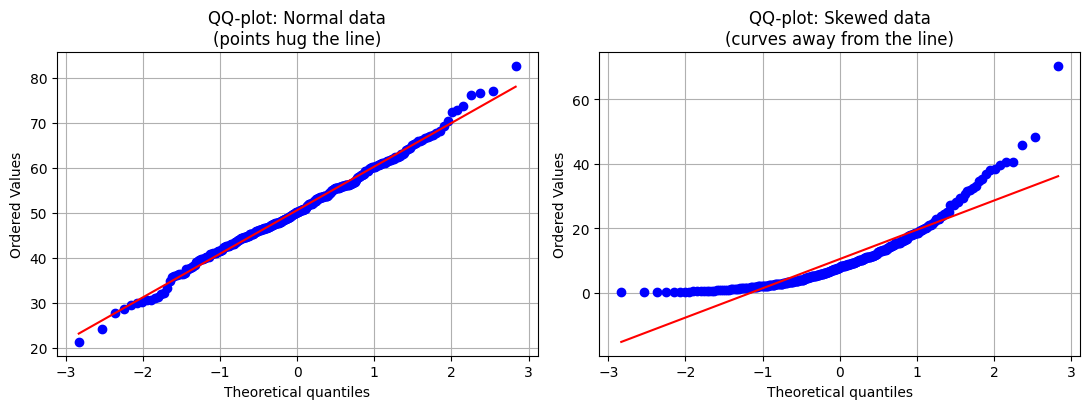

Shapiro-Wilk on Normal data : W=0.9951, p=0.4519  -> fails to reject normality
Shapiro-Wilk on Skewed data : W=0.8314, p=2.105e-17  -> rejects normality


In [14]:
normal_data = rng.normal(50, 10, 300)
skewed_data = rng.exponential(10, 300)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
stats.probplot(normal_data, dist="norm", plot=axes[0]); axes[0].set_title("QQ-plot: Normal data\n(points hug the line)")
stats.probplot(skewed_data, dist="norm", plot=axes[1]); axes[1].set_title("QQ-plot: Skewed data\n(curves away from the line)")
plt.tight_layout(); plt.show()

sw_normal = stats.shapiro(normal_data)
sw_skewed = stats.shapiro(skewed_data)
print(f"Shapiro-Wilk on Normal data : W={sw_normal.statistic:.4f}, p={sw_normal.pvalue:.4f}  -> {'fails to reject normality' if sw_normal.pvalue>0.05 else 'rejects normality'}")
print(f"Shapiro-Wilk on Skewed data : W={sw_skewed.statistic:.4f}, p={sw_skewed.pvalue:.4g}  -> {'fails to reject normality' if sw_skewed.pvalue>0.05 else 'rejects normality'}")

---
# Real-Life Case Studies
---

## 13. Case Study 1: Adult Height & Manufacturing Tolerances

Adult male height (a trait shaped by countless additive genetic + environmental factors — a textbook CLT scenario) is well modelled as $H\sim N(175,\ 7^2)$ cm.

**Questions**
1. What fraction of men are taller than 190 cm?
2. A doorway is designed so only 0.5% of men must duck. How tall should the doorway be?
3. A clothing company makes shirts for the **middle 80%** of the height range. What are the cut-off heights?
4. **Manufacturing angle:** a bolt is specified as 30 mm ± 0.3 mm (i.e. anything outside [29.7, 30.3] is rejected). If the production process gives $X\sim N(30.05,\ 0.12^2)$ (slightly off-centre!), what fraction of bolts are rejected?

In [15]:
H = stats.norm(175, 7)

print(f"1. P(height > 190 cm) = {H.sf(190):.4f}  (about 1 in {1/H.sf(190):.0f} men)")
print(f"2. Doorway height for only 0.5% to duck = {H.ppf(0.995):.1f} cm")

lo, hi = H.ppf(0.10), H.ppf(0.90)
print(f"3. Middle 80% of heights: {lo:.1f} cm to {hi:.1f} cm")

bolt = stats.norm(30.05, 0.12)
reject = bolt.cdf(29.7) + bolt.sf(30.3)
print(f"\n4. Bolt spec [29.7, 30.3] mm, process centred at 30.05 (off-target!):")
print(f"   Rejected fraction = {reject:.4%}")

bolt_centered = stats.norm(30.00, 0.12)
reject_centered = bolt_centered.cdf(29.7) + bolt_centered.sf(30.3)
print(f"   If centred at 30.00 instead: rejected fraction = {reject_centered:.4%}  <- big improvement!")

1. P(height > 190 cm) = 0.0161  (about 1 in 62 men)
2. Doorway height for only 0.5% to duck = 193.0 cm
3. Middle 80% of heights: 166.0 cm to 184.0 cm

4. Bolt spec [29.7, 30.3] mm, process centred at 30.05 (off-target!):
   Rejected fraction = 2.0379%
   If centred at 30.00 instead: rejected fraction = 1.2419%  <- big improvement!


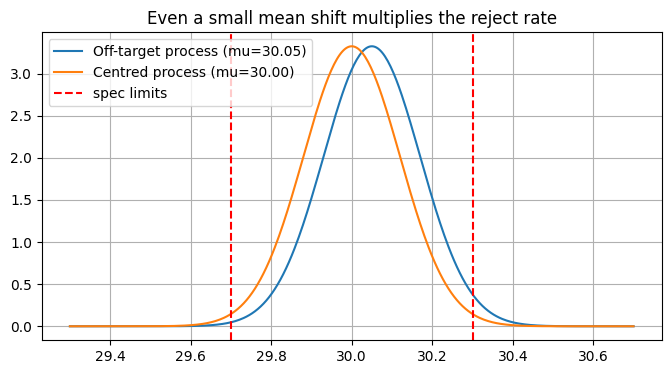

In [16]:
x = np.linspace(29.3, 30.7, 400)
plt.plot(x, bolt.pdf(x), label="Off-target process (mu=30.05)")
plt.plot(x, bolt_centered.pdf(x), label="Centred process (mu=30.00)")
plt.axvline(29.7, color="red", ls="--"); plt.axvline(30.3, color="red", ls="--", label="spec limits")
plt.legend(); plt.title("Even a small mean shift multiplies the reject rate"); plt.show()

### 💡 Insights (Case Study 1)
* **Tail probabilities fall off very fast**: 190 cm is only ~2.1σ above the mean, yet already only about 1.6% of men (roughly 1 in 62) are taller.
* **Design-for-population thinking:** doorways, seats, PPE and equipment sizing all use Normal percentiles (this is literally called "anthropometric design").
* **A small shift in the mean has an outsized effect on rejects.** Moving the bolt process mean by just 0.05 mm (well under half a standard deviation) pushes the reject rate up from 1.24% to 2.04% — over 60% more rejects — just from being slightly off-centre. This is why manufacturing obsesses over keeping a process *centred*, not just "within spec on average". This idea returns in Section 16 (process capability).

## 14. Case Study 2: Exam Scores, Grading on a Curve & Percentile Ranks

A university exam has scores $S\sim N(68,\ 12^2)$ (out of 100).

**Questions**
1. A student scores 85. What percentile are they at? What's their z-score?
2. The professor wants to give an "A" to the top 10% of students. What's the cutoff score?
3. **Grading on a curve:** assign letter grades so that A = top 10%, B = next 25%, C = middle 30%, D = next 25%, F = bottom 10%. Find all the cutoffs.
4. Two students take *different* exams: Student X scores 78 on Exam 1 ~ N(70, 10²); Student Y scores 82 on Exam 2 ~ N(75, 8²). Who performed *relatively* better?

In [17]:
S = stats.norm(68, 12)

score = 85
z = (score - 68) / 12
pct = S.cdf(score)
print(f"1. Score 85: z = {z:.3f}, percentile = {pct:.1%} (better than {pct:.1%} of the class)")

a_cutoff = S.ppf(0.90)
print(f"2. Top-10% (A grade) cutoff = {a_cutoff:.1f}")

print("\n3. Grade cutoffs:")
cum = 0
for grade, share in [("F", 0.10), ("D", 0.25), ("C", 0.30), ("B", 0.25), ("A", 0.10)]:
    cum += share
    if grade != "A":
        print(f"   {grade}: score < {S.ppf(cum):.1f}")
    else:
        print(f"   {grade}: score >= {S.ppf(1-share):.1f}")

1. Score 85: z = 1.417, percentile = 92.2% (better than 92.2% of the class)
2. Top-10% (A grade) cutoff = 83.4

3. Grade cutoffs:
   F: score < 52.6
   D: score < 63.4
   C: score < 72.6
   B: score < 83.4
   A: score >= 83.4


In [18]:
X1 = stats.norm(70, 10)   # Exam 1
X2 = stats.norm(75, 8)    # Exam 2
zx, zy = (78 - 70) / 10, (82 - 75) / 8
print(f"4. Student X: z = {zx:.3f} -> percentile {X1.cdf(78):.1%}")
print(f"   Student Y: z = {zy:.3f} -> percentile {X2.cdf(82):.1%}")
print("   ->", "Student Y did relatively better" if zy > zx else "Student X did relatively better")

4. Student X: z = 0.800 -> percentile 78.8%
   Student Y: z = 0.875 -> percentile 80.9%
   -> Student Y did relatively better


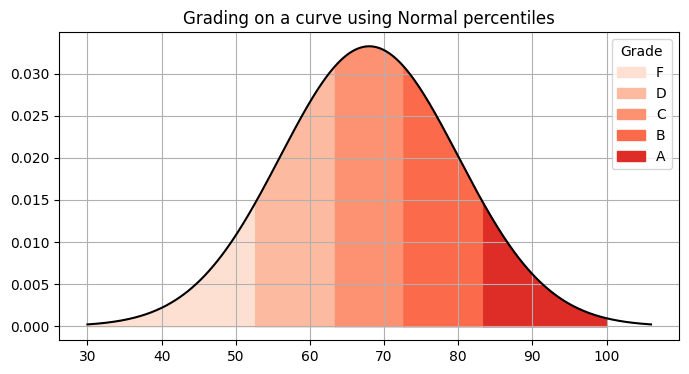

In [19]:
x = np.linspace(30, 106, 400)
plt.plot(x, S.pdf(x), "k")
bounds = [0] + [S.ppf(c) for c in np.cumsum([0.10, 0.25, 0.30, 0.25])] + [100]
labels = ["F", "D", "C", "B", "A"]
colors = ["#fee0d2", "#fcbba1", "#fc9272", "#fb6a4a", "#de2d26"]
for lo_, hi_, lab, col in zip(bounds[:-1], bounds[1:], labels, colors):
    xs = np.linspace(max(lo_, 30), min(hi_, 106), 100)
    plt.fill_between(xs, S.pdf(xs), color=col, label=lab)
plt.legend(title="Grade"); plt.title("Grading on a curve using Normal percentiles"); plt.show()

### 💡 Insights (Case Study 2)
* **Z-scores let you compare apples to oranges** — two different exams, two different scales — by converting each to "number of SDs above the mean". Here Student Y (z = 0.875) actually outperformed Student X (z = 0.80) *relatively*, even though the gap in raw scores (82 vs 78) might look similar either way.
* **Percentile ≠ score.** An 85 might sound "good" in absolute terms, but its real meaning only comes from where it sits in the distribution.
* Grading-on-a-curve is literally the Normal **quantile function** applied to fixed population shares — this is the same maths used for standardized test score bands (percentiles) like the SAT/GRE.

## 15. Case Study 3: Financial Returns, Value at Risk & the Danger of "Fat Tails"

A stock's **daily return** is modelled (as a first approximation) as $R\sim N(0.0005,\ 0.02^2)$ (0.05% average daily return, 2% daily volatility).

**Questions**
1. What's the probability of losing more than 3% in a single day?
2. **Value at Risk (VaR):** the loss threshold not exceeded 95% of the time (a common risk metric). What's the 1-day 95% VaR on a ₹1,000,000 portfolio?
3. Over a **year (252 trading days)**, what's the distribution of total return (assuming independence)? What's the probability of a positive year?
4. **The catch:** real markets have "fat tails" — extreme moves happen more often than Normal predicts. Compare the Normal model against real-looking heavy-tailed data (Student-t) for the chance of a crash (>5% single-day loss).

In [20]:
R = stats.norm(0.0005, 0.02)

print(f"1. P(single-day loss > 3%) = P(R < -0.03) = {R.cdf(-0.03):.4%}")

var95 = -R.ppf(0.05)
portfolio = 1_000_000
print(f"2. 1-day 95% VaR = {var95:.4%} of portfolio = Rs {var95*portfolio:,.0f}")
print(f"   (In 95% of days, losses will be smaller than this; in 5% of days, they exceed it)")

n_days = 252
mu_annual = 252 * 0.0005
sd_annual = 0.02 * sqrt(252)
R_annual = stats.norm(mu_annual, sd_annual)
print(f"\n3. Annual return ~ N({mu_annual:.3f}, {sd_annual:.3f} sq), i.e. mean {mu_annual:.1%}, SD {sd_annual:.1%}")
print(f"   P(positive year) = {R_annual.sf(0):.2%}")

1. P(single-day loss > 3%) = P(R < -0.03) = 6.3630%
2. 1-day 95% VaR = 3.2397% of portfolio = Rs 32,397
   (In 95% of days, losses will be smaller than this; in 5% of days, they exceed it)

3. Annual return ~ N(0.126, 0.317 sq), i.e. mean 12.6%, SD 31.7%
   P(positive year) = 65.43%


P(single-day loss > 5%): Normal model  = 0.578491%  (1 in 173 days)
P(single-day loss > 5%): Fat-tail model = 1.167858%  (1 in 86 days)

Ratio: the fat-tailed model says crashes are 2x more likely than the Normal model predicts!


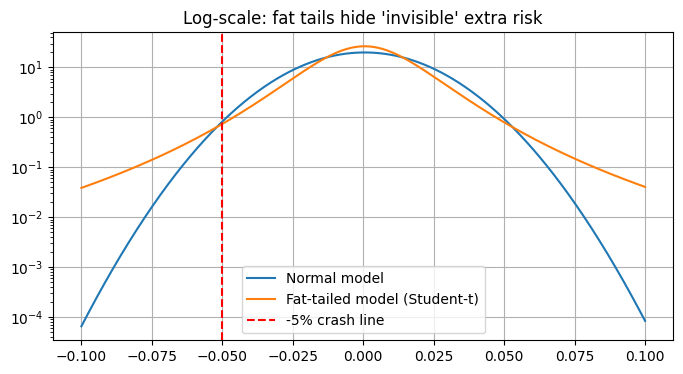

In [21]:
t_dist = stats.t(df=4, loc=0.0005, scale=0.02 * sqrt((4-2)/4))

p_crash_normal = R.cdf(-0.05)
p_crash_fat = t_dist.cdf(-0.05)
print(f"P(single-day loss > 5%): Normal model  = {p_crash_normal:.6%}  (1 in {1/p_crash_normal:,.0f} days)")
print(f"P(single-day loss > 5%): Fat-tail model = {p_crash_fat:.6%}  (1 in {1/p_crash_fat:,.0f} days)")
print(f"\nRatio: the fat-tailed model says crashes are {p_crash_fat/p_crash_normal:.0f}x more likely than the Normal model predicts!")

x = np.linspace(-0.1, 0.1, 500)
plt.plot(x, R.pdf(x), label="Normal model")
plt.plot(x, t_dist.pdf(x), label="Fat-tailed model (Student-t)")
plt.axvline(-0.05, color="red", ls="--", label="-5% crash line")
plt.legend(); plt.yscale("log"); plt.title("Log-scale: fat tails hide 'invisible' extra risk"); plt.show()

### 💡 Insights (Case Study 3)
* Normal-based risk models (VaR, options pricing formulas like Black-Scholes) are extremely convenient — but they can **badly underestimate the chance of extreme crashes**, because real financial returns have heavier tails than Normal. This mismatch was a contributing factor in several historical financial crises.
* On a log-scale plot, the gap between "Normal" and "fat-tailed" is small near the centre but **enormous** in the tails — exactly where it matters most for risk.
* **Lesson:** Normal is a great *starting* model (mean & variance are easy to estimate, math is tractable), but always ask "what does the *tail* really look like?" before betting real money or safety margins on it.

## 16. Case Study 4: Quality Control — Process Capability (Cp, Cpk) & Six Sigma

A machine fills bottles with a target of **500 ml**, with spec limits **LSL = 490 ml, USL = 510 ml** (Lower/Upper Spec Limit). The filling process has $X\sim N(\mu,\sigma^2)$.

**Process capability indices** measure whether the *process spread* fits inside the *spec limits*:

$$C_p=\frac{USL-LSL}{6\sigma}\qquad\qquad C_{pk}=\min\!\left(\frac{USL-\mu}{3\sigma},\ \frac{\mu-LSL}{3\sigma}\right)$$

* $C_p$ compares the spec **width** to the natural process spread (6σ) — ignores centring.
* $C_{pk}$ also accounts for how **centred** the process is. $C_{pk}\le C_p$ always; they're equal only when perfectly centred.
* Rule of thumb: $C_{pk}\ge 1.33$ is generally considered capable; $C_{pk}\ge 2.0$ is "Six Sigma" quality.

In [22]:
LSL, USL = 490, 510

def capability(mu, sigma):
    Cp = (USL - LSL) / (6 * sigma)
    Cpk = min((USL - mu) / (3 * sigma), (mu - LSL) / (3 * sigma))
    X = stats.norm(mu, sigma)
    defect_rate = X.cdf(LSL) + X.sf(USL)
    return Cp, Cpk, defect_rate

scenarios = {
    "Well-centred, tight (sigma=1.5)":  (500, 1.5),
    "Well-centred, loose (sigma=3.0)":  (500, 3.0),
    "Off-centre, tight (sigma=1.5)":    (503, 1.5),
    "Six-sigma target (sigma=1.67)":    (500, 1.67),
}
rows = []
for name, (mu, sigma) in scenarios.items():
    Cp, Cpk, defect = capability(mu, sigma)
    rows.append({"scenario": name, "mu": mu, "sigma": sigma, "Cp": round(Cp, 2), "Cpk": round(Cpk, 2),
                 "defects (ppm)": round(defect * 1e6, 1)})
print(pd.DataFrame(rows).to_string(index=False))

                       scenario  mu  sigma   Cp  Cpk  defects (ppm)
Well-centred, tight (sigma=1.5) 500   1.50 2.22 2.22            0.0
Well-centred, loose (sigma=3.0) 500   3.00 1.11 1.11          858.1
  Off-centre, tight (sigma=1.5) 503   1.50 2.22 1.56            1.5
  Six-sigma target (sigma=1.67) 500   1.67 2.00 2.00            0.0


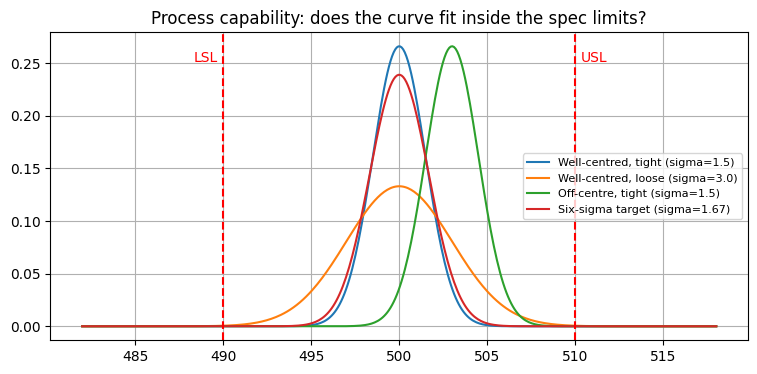

In [23]:
x = np.linspace(482, 518, 400)
fig, ax = plt.subplots(figsize=(9, 4))
for name, (mu, sigma) in scenarios.items():
    ax.plot(x, stats.norm.pdf(x, mu, sigma), label=f"{name}")
ax.axvline(LSL, color="red", ls="--"); ax.axvline(USL, color="red", ls="--")
ax.text(LSL-0.3, ax.get_ylim()[1]*0.9, "LSL", color="red", ha="right")
ax.text(USL+0.3, ax.get_ylim()[1]*0.9, "USL", color="red")
ax.legend(fontsize=8); ax.set_title("Process capability: does the curve fit inside the spec limits?")
plt.show()

### 💡 Insights (Case Study 4)
* **Both centring and reducing variation (σ) matter, and Cpk captures both.** Compare the four scenarios above: a well-centred, tight process gets Cpk = 2.22 with essentially zero defects, while the same tight process shifted off-centre drops to Cpk = 1.56 — still capable, but measurably worse. A well-centred yet *loose* process (σ = 3.0) has the worst defect rate of all (858 ppm) despite being perfectly centred, showing that centring alone cannot make up for excess variation.
* At exactly **Cpk = 1.33** (a common industry minimum), the defect rate is already down to a few dozen parts-per-million. Pushing to "Six Sigma" (Cpk ≈ 2.0, defects near zero in theory) requires disproportionately tighter control — a classic case of diminishing (but sometimes still worthwhile) returns.
* This is the direct extension of Case Study 1's "off-target bolt process" — Cp/Cpk turn that same intuition into a **standard industrial metric** used across manufacturing, pharma and electronics.

## 17. Case Study 5: Confidence Intervals — Estimating a Population Mean

A food company wants to know the true **average sugar content** of its cereal (population mean μ, unknown). They sample **36 boxes** and measure sugar content (grams). Sample mean $\bar x = 12.4$ g, sample SD $s = 1.8$ g.

Because $\bar X$ is (approximately, by the CLT) Normal, a **confidence interval** for μ is:

$$\bar x\ \pm\ z^*\cdot\frac{s}{\sqrt n}$$

**Questions**
1. Build a 95% confidence interval for the true mean sugar content.
2. How does the interval narrow if the sample size is increased to 144 (4×)?
3. Simulate many experiments: does a 95% CI really "capture" the true mean about 95% of the time?

In [24]:
xbar, s, n = 12.4, 1.8, 36
se = s / sqrt(n)

for conf in (0.90, 0.95, 0.99):
    z = stats.norm.ppf(1 - (1 - conf) / 2)
    margin = z * se
    print(f"{conf:.0%} CI: {xbar:.2f} +/- {margin:.3f}  ->  ({xbar-margin:.3f}, {xbar+margin:.3f}) g")

90% CI: 12.40 +/- 0.493  ->  (11.907, 12.893) g
95% CI: 12.40 +/- 0.588  ->  (11.812, 12.988) g
99% CI: 12.40 +/- 0.773  ->  (11.627, 13.173) g


In [25]:
for n_ in (36, 144):
    se_ = s / sqrt(n_)
    margin = 1.96 * se_
    print(f"n = {n_:3d}: SE = {se_:.4f}, 95% margin = +/-{margin:.3f}")
print("\nQuadrupling n HALVES the margin of error (because SE is proportional to 1/sqrt(n)) - diminishing returns on sample size.")

n =  36: SE = 0.3000, 95% margin = +/-0.588
n = 144: SE = 0.1500, 95% margin = +/-0.294

Quadrupling n HALVES the margin of error (because SE is proportional to 1/sqrt(n)) - diminishing returns on sample size.


Out of 5000 simulated 95% CIs, 4713 (94.26%) captured the true mean.
(Should be close to 95% - that's exactly what '95% confidence' means: the PROCEDURE succeeds 95% of the time.)


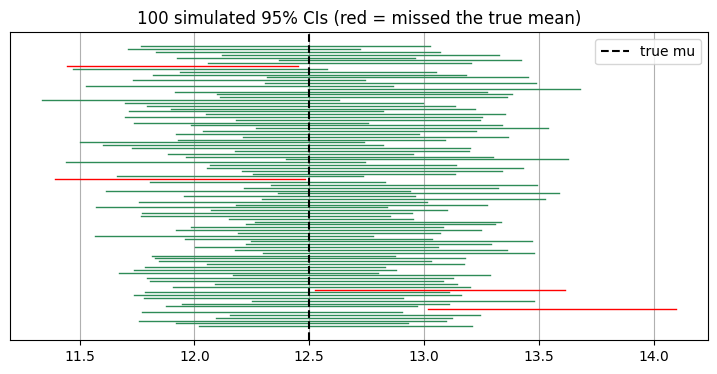

In [26]:
true_mu, true_sigma, n = 12.5, 1.8, 36
n_experiments = 5000
z = stats.norm.ppf(0.975)

captured = 0
intervals = []
for i in range(n_experiments):
    sample = rng.normal(true_mu, true_sigma, n)
    m, se_ = sample.mean(), sample.std(ddof=1) / sqrt(n)
    lo, hi = m - z*se_, m + z*se_
    intervals.append((lo, hi, lo <= true_mu <= hi))
    if lo <= true_mu <= hi:
        captured += 1

print(f"Out of {n_experiments} simulated 95% CIs, {captured} ({captured/n_experiments:.2%}) captured the true mean.")
print("(Should be close to 95% - that's exactly what '95% confidence' means: the PROCEDURE succeeds 95% of the time.)")

fig, ax = plt.subplots(figsize=(9, 4))
sample_ivs = intervals[:100]
for i, (lo, hi, ok) in enumerate(sample_ivs):
    ax.plot([lo, hi], [i, i], color="seagreen" if ok else "red", lw=1)
ax.axvline(true_mu, color="black", ls="--", label="true mu")
ax.set_title("100 simulated 95% CIs (red = missed the true mean)"); ax.set_yticks([]); ax.legend(); plt.show()

### 💡 Insights (Case Study 5)
* A "95% confidence interval" does **not** mean "95% probability the true mean is in this specific interval". It means: **if we repeated this sampling procedure many times, about 95% of the resulting intervals would contain the true mean.** The simulation makes this concrete.
* **Precision scales with 1/√n**, not 1/n. To halve your margin of error, you need **4×** the sample — a crucial (and expensive) fact for survey design and experiment planning.
* This entire machinery relies on $\bar X$ being approximately Normal — which holds either because the underlying data is Normal, or (more commonly) thanks to the **CLT**, even when individual measurements are not.

## 18. Estimating μ and σ from Data (Maximum Likelihood)

Given data $x_1,\dots,x_n$ believed to come from $N(\mu,\sigma^2)$, the **maximum likelihood estimates** are:

$$\hat\mu=\bar x=\frac1n\sum x_i\qquad\qquad\hat\sigma^2=\frac1n\sum(x_i-\bar x)^2$$

Note: the MLE of variance divides by **n**, not n−1 (it's slightly biased; the unbiased sample variance $s^2$ with n−1 is preferred for inference — see the earlier central-tendency/dispersion notebook for why).

True mu = 40, sigma = 6
MLE:        mu_hat = 39.631,  sigma_hat(MLE, /n) = 5.680
Unbiased:   s (divide by n-1)      = 5.695


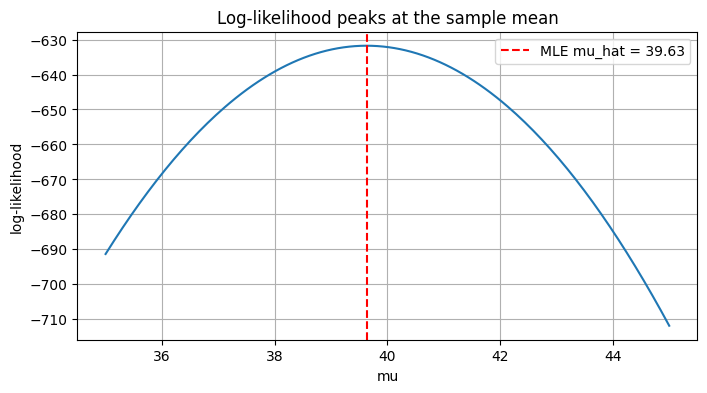

In [27]:
true_mu, true_sigma = 40, 6
data = rng.normal(true_mu, true_sigma, 200)

mu_hat = data.mean()
sigma_hat_mle = np.sqrt(np.mean((data - mu_hat)**2))
sigma_hat_unbiased = data.std(ddof=1)

print(f"True mu = {true_mu}, sigma = {true_sigma}")
print(f"MLE:        mu_hat = {mu_hat:.3f},  sigma_hat(MLE, /n) = {sigma_hat_mle:.3f}")
print(f"Unbiased:   s (divide by n-1)      = {sigma_hat_unbiased:.3f}")

mus = np.linspace(35, 45, 200)
ll = [np.sum(stats.norm.logpdf(data, m, true_sigma)) for m in mus]
plt.plot(mus, ll); plt.axvline(mu_hat, color="red", ls="--", label=f"MLE mu_hat = {mu_hat:.2f}")
plt.xlabel("mu"); plt.ylabel("log-likelihood"); plt.legend(); plt.title("Log-likelihood peaks at the sample mean"); plt.show()

## 19. Cheat-Sheet, Key Insights & Practice Problems

### Formulas
| Item | Formula |
|---|---|
| PDF | $f(x)=\frac{1}{\sigma\sqrt{2\pi}}e^{-(x-\mu)^2/2\sigma^2}$ |
| Mean = Median = Mode | μ |
| Variance / Std dev | σ² / σ |
| Standardisation | $Z=(X-\mu)/\sigma$ |
| Empirical rule | 68% / 95% / 99.7% within ±1σ/±2σ/±3σ |
| Linear transform | $aX+b\sim N(a\mu+b,\ a^2\sigma^2)$ |
| Independent sum | $X_1+X_2\sim N(\mu_1+\mu_2,\ \sigma_1^2+\sigma_2^2)$ |
| Sample mean (CLT) | $\bar X\approx N(\mu,\ \sigma^2/n)$ |
| Confidence interval | $\bar x\pm z^*\,s/\sqrt n$ |
| MLE | $\hat\mu=\bar x,\ \hat\sigma^2=\frac1n\sum(x_i-\bar x)^2$ |

### scipy cheat-sheet
* `stats.norm(mu, sigma)` creates the distribution object
* `.pdf(x)`, `.cdf(x)`, `.sf(x)` = 1−cdf, `.ppf(q)` = inverse CDF, `.rvs(size)` = random samples

### Top real-life insights
1. **Mean = median = mode = μ**, and everything is symmetric — a huge simplification versus skewed distributions.
2. **The Empirical Rule (68-95-99.7)** is the fastest mental sanity-check for "is this value normal or surprising?"
3. **Small shifts in μ can hugely change tail probabilities** (defect rates, pass rates) — centring a process is often as important as tightening it.
4. **The CLT is why Normal shows up everywhere**: averages/sums of many small independent effects are approximately Normal, even when individual pieces aren't.
5. **Precision (of an estimate) improves like 1/√n**, not 1/n — a fundamental limit on how much sample size alone can buy you.
6. **Real-world tails are often fatter than Normal predicts** (finance, natural disasters, extreme events) — never blindly trust the Normal model far out in the tails without checking.
7. **A 95% CI is about the *procedure*, not a single interval** — a subtlety that trips up even experienced practitioners.

### Practice problems
1. Adult cat weights are N(4.5, 0.6²) kg. Find P(weight > 5.5 kg), the 25th percentile, and the weight range containing the middle 50%.
2. A factory's rod lengths are N(50, 0.4²) cm, spec limits [49, 51] cm. Compute Cp and Cpk, and the defect rate in ppm.
3. IQ scores are N(100, 15²). What score is needed to be in the top 2%? What fraction of people score between 85 and 115?
4. A sample of 50 batteries has mean life 300 hours, SD 20 hours. Build a 99% CI for the true mean life. How large a sample is needed to get the margin of error down to ±2 hours?
5. Show by simulation that if $X_1\sim N(10,2^2)$ and $X_2\sim N(15,3^2)$ are independent, then $2X_1 - X_2$ is Normal, and verify its theoretical mean and variance.
6. Daily temperature deviations from seasonal average are modelled as N(0, 3²)°C. Using a heavier-tailed alternative (Student-t, df=5, same SD), compare P(deviation > 10°C) under both models. What does this say about relying on Normal for extreme-weather risk?
7. Generate 500 samples from a Normal and 500 from a skewed distribution (e.g. exponential). Run Shapiro-Wilk and draw QQ-plots for both. Confirm the test/plot correctly distinguishes them.